# UK Used Car Price Prediction: 02. Exploratory Data Analysis (EDA)

Notebook ini mengeksplorasi data yang sudah dibersihkan di notebook 01 untuk memahami variabel target (`price`) dan hubungannya dengan fitur-fitur lain, sebelum masuk ke pemodelan.

**Input:** `data/processed/cars_clean.csv` (hasil notebook 01, jalankan notebook 01 dulu).
**Output:** grafik di `reports/figures/` dan catatan temuan di bagian akhir.

**Catatan:** EDA hanya untuk memahami data. Tidak ada keputusan yang memakai test set di sini, karena split train/test dilakukan di notebook berikutnya.

## 1. Setup dan Load Data

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA = Path("../data/processed/cars_clean.csv")
FIG = Path("../reports/figures")
FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA)
print(df.shape)
df.head()

(97411, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi


In [2]:
# Fitur umur mobil. Asumsi: data diambil sekitar pertengahan 2020.
REF_YEAR = 2020
df["car_age"] = REF_YEAR - df["year"]

print(df["car_age"].describe().round(2))
print("\nJumlah baris per merek:")
print(df["brand"].value_counts().to_string())

count    97411.00
mean         2.93
std          2.11
min          0.00
25%          1.00
50%          3.00
75%          4.00
max         24.00
Name: car_age, dtype: float64

Jumlah baris per merek:
brand
ford        17759
vw          14877
vauxhall    13224
merc        12845
bmw         10605
audi        10513
toyota       6682
skoda        6183
hyundi       4723


## 2. Distribusi Harga (Target)

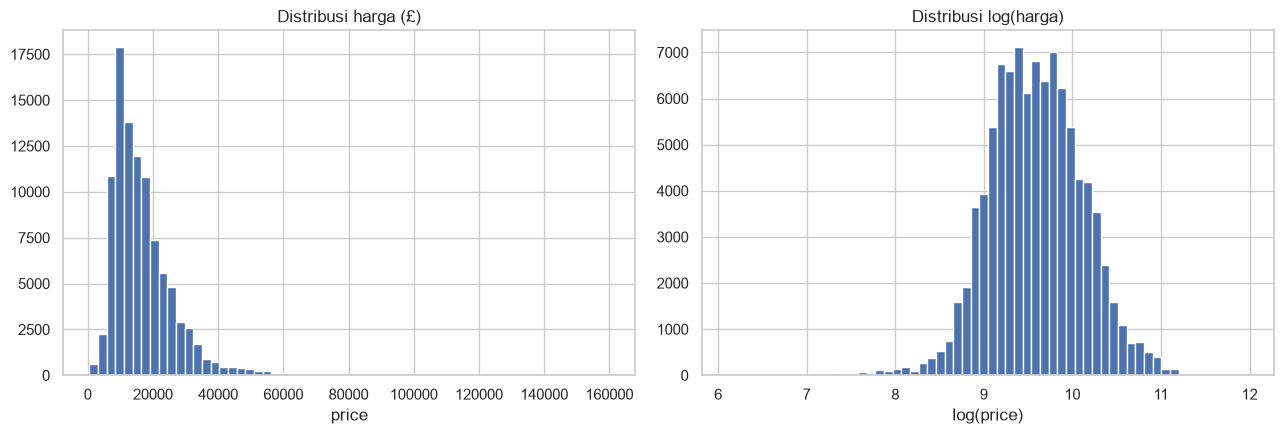

skewness harga      : 2.37
skewness log(harga) : -0.08

count     97411.0
mean      16768.0
std        9865.0
min         450.0
25%        9999.0
50%       14461.0
75%       20750.0
max      159999.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["price"], bins=60)
axes[0].set_title("Distribusi harga (£)")
axes[0].set_xlabel("price")

axes[1].hist(np.log(df["price"]), bins=60)
axes[1].set_title("Distribusi log(harga)")
axes[1].set_xlabel("log(price)")

plt.tight_layout()
plt.savefig(FIG / "eda_price_distribution.png", dpi=150)
plt.show()

print("skewness harga      :", round(df["price"].skew(), 2))
print("skewness log(harga) :", round(np.log(df["price"]).skew(), 2))
print()
print(df["price"].describe().round(0).to_string())

## 3. Harga vs Umur dan Mileage

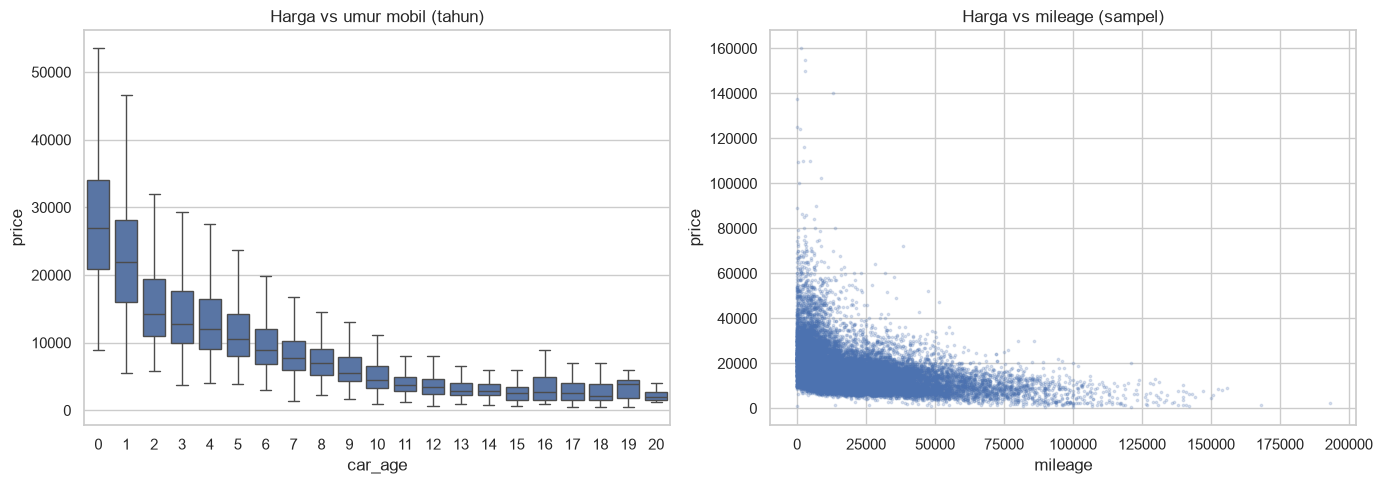

Korelasi Spearman dengan harga:
  car_age : -0.599
  mileage : -0.511
Korelasi Spearman umur vs mileage: 0.809


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot harga per umur (dibatasi <= 20 tahun agar terbaca; outlier disembunyikan)
sub = df[df["car_age"] <= 20]
sns.boxplot(data=sub, x="car_age", y="price", showfliers=False, ax=axes[0])
axes[0].set_title("Harga vs umur mobil (tahun)")

# Scatter mileage vs harga (sampel agar ringan)
samp = df.sample(min(20000, len(df)), random_state=42)
axes[1].scatter(samp["mileage"], samp["price"], s=3, alpha=0.2)
axes[1].set_title("Harga vs mileage (sampel)")
axes[1].set_xlabel("mileage")
axes[1].set_ylabel("price")

plt.tight_layout()
plt.savefig(FIG / "eda_price_vs_age_mileage.png", dpi=150)
plt.show()

print("Korelasi Spearman dengan harga:")
print("  car_age :", round(df["price"].corr(df["car_age"], method="spearman"), 3))
print("  mileage :", round(df["price"].corr(df["mileage"], method="spearman"), 3))
print("Korelasi Spearman umur vs mileage:",
      round(df["car_age"].corr(df["mileage"], method="spearman"), 3))

## 4. Harga per Merek

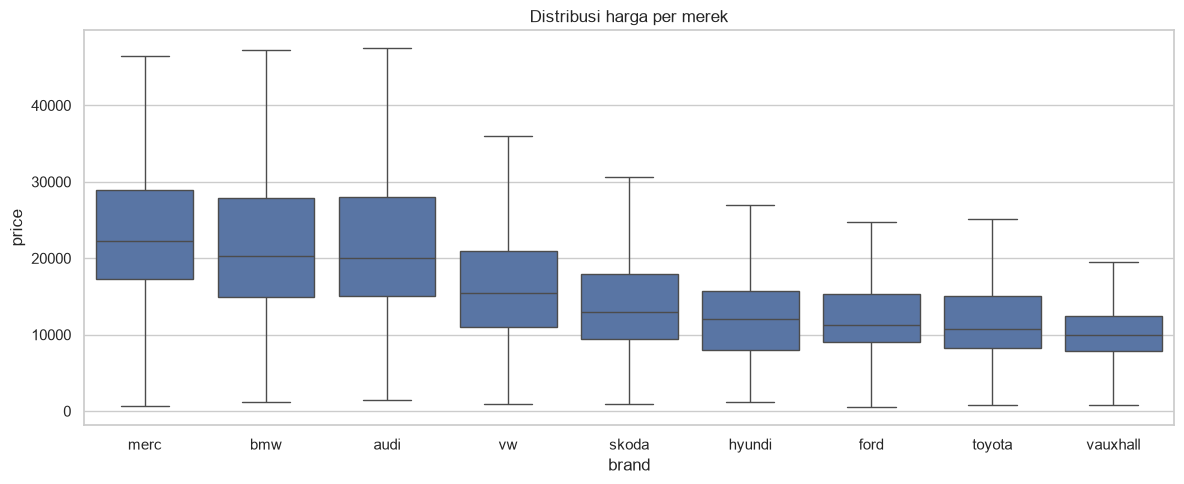

,jumlah,median,rata_rata
brand,,,
merc,12845,22299.0,24641.0
bmw,10605,20295.0,22685.0
audi,10513,20000.0,22815.0
vw,14877,15491.0,16808.0
skoda,6183,12998.0,14286.0
hyundi,4723,11995.0,12742.0
ford,17759,11290.0,12272.0
toyota,6682,10795.0,12508.0
vauxhall,13224,9998.0,10313.0


In [5]:
order = df.groupby("brand")["price"].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="brand", y="price", order=order, showfliers=False)
plt.title("Distribusi harga per merek")
plt.tight_layout()
plt.savefig(FIG / "eda_price_by_brand.png", dpi=150)
plt.show()

summary = (df.groupby("brand")["price"]
             .agg(jumlah="count", median="median", rata_rata="mean")
             .round(0)
             .loc[order])
summary

## 5. Transmission dan Fuel Type

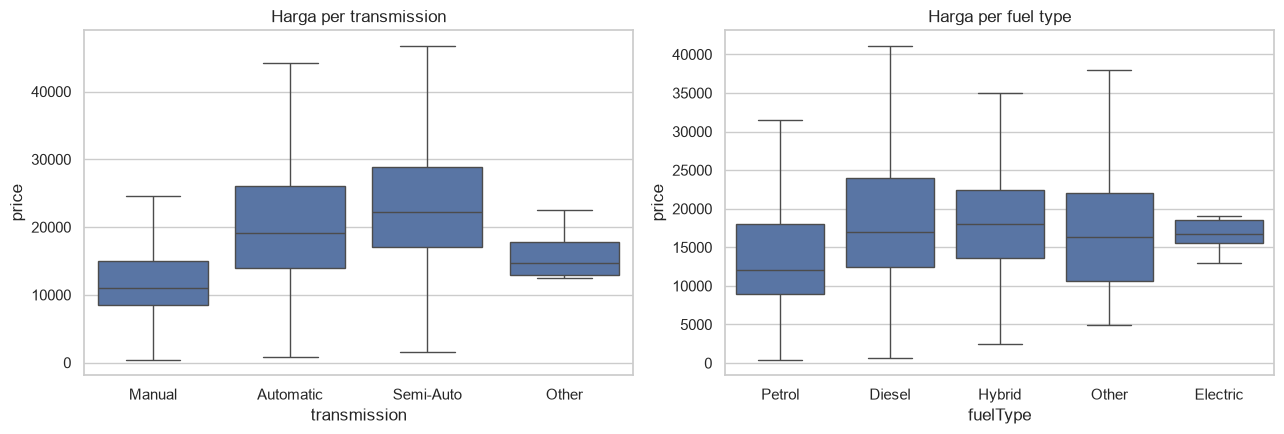

              jumlah   median
transmission                 
Automatic      19781  19200.0
Manual         55340  11000.0
Other              8  14749.0
Semi-Auto      22282  22245.0 

          jumlah   median
fuelType                 
Diesel     40340  17000.0
Electric       6  16688.0
Hybrid      3000  17999.0
Other        245  16400.0
Petrol     53820  11998.0 



In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x="transmission", y="price", showfliers=False, ax=axes[0])
axes[0].set_title("Harga per transmission")

sns.boxplot(data=df, x="fuelType", y="price", showfliers=False, ax=axes[1])
axes[1].set_title("Harga per fuel type")

plt.tight_layout()
plt.savefig(FIG / "eda_price_by_categories.png", dpi=150)
plt.show()

# Perhatikan jumlah baris tiap kategori: kategori kecil kurang bisa diandalkan
for col in ["transmission", "fuelType"]:
    print(df.groupby(col)["price"].agg(jumlah="count", median="median").round(0), "\n")

## 6. Engine Size, MPG, dan Tax

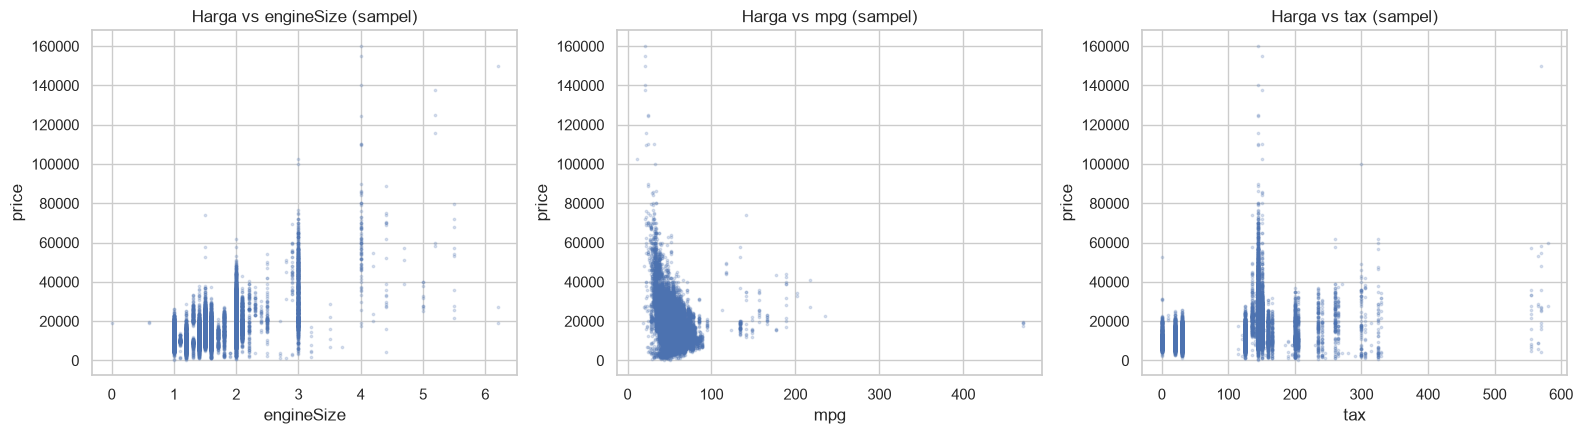

Jumlah baris mpg > 100 (plug-in hybrid, dipertahankan di cleaning): 530
Jumlah baris tax == 0: 6221


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col in zip(axes, ["engineSize", "mpg", "tax"]):
    ax.scatter(samp[col], samp["price"], s=3, alpha=0.2)
    ax.set_title(f"Harga vs {col} (sampel)")
    ax.set_xlabel(col)
    ax.set_ylabel("price")

plt.tight_layout()
plt.savefig(FIG / "eda_price_vs_engine_mpg_tax.png", dpi=150)
plt.show()

print("Jumlah baris mpg > 100 (plug-in hybrid, dipertahankan di cleaning):",
      (df["mpg"] > 100).sum())
print("Jumlah baris tax == 0:", (df["tax"] == 0).sum())

## 7. Korelasi Antar Fitur Numerik

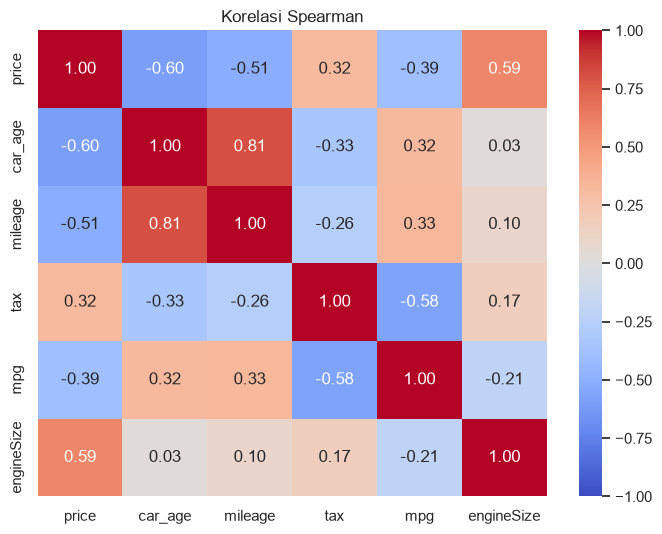

car_age      -0.599
engineSize    0.592
mileage      -0.511
mpg          -0.392
tax           0.318


In [8]:
num_cols = ["price", "car_age", "mileage", "tax", "mpg", "engineSize"]
corr = df[num_cols].corr(method="spearman")

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korelasi Spearman")
plt.tight_layout()
plt.savefig(FIG / "eda_correlation_heatmap.png", dpi=150)
plt.show()

print(corr["price"].drop("price").sort_values(key=abs, ascending=False).round(3).to_string())

In [9]:
# 1. Titik mpg ekstrem
print(df.loc[df["mpg"] > 200, ["brand", "model", "year", "fuelType", "mpg", "price"]]
        .sort_values("mpg", ascending=False).to_string())

# 2. Apakah tax mencerminkan umur/tahun registrasi?
print(pd.crosstab(df["year"], pd.cut(df["tax"], [-1, 0, 100, 200, 300, 600])).to_string())

          brand    model  year  fuelType    mpg  price
10545       bmw       i3  2016     Other  470.8  17100
18543       bmw       i3  2015     Other  470.8  14940
18730       bmw       i3  2017  Electric  470.8  18999
18755       bmw       i3  2016  Electric  470.8  18999
18974       bmw       i3  2017     Other  470.8  19300
19183       bmw       i3  2015  Electric  470.8  17400
20418       bmw       i3  2017     Other  470.8  20000
20424       bmw       i3  2017     Other  470.8  19500
20662       bmw       i3  2016     Other  470.8  17000
20867       bmw       i3  2017     Other  470.8  17600
40035    hyundi    Ioniq  2018    Hybrid  256.8  18970
40888    hyundi    Ioniq  2019    Hybrid  256.8  19995
41011    hyundi    Ioniq  2018    Hybrid  256.8  18999
82220  vauxhall   Ampera  2015  Electric  235.4  12999
68718    toyota    Prius  2017    Hybrid  235.0  20998
68700    toyota    Prius  2017    Hybrid  235.0  19998
68791    toyota    Prius  2019    Hybrid  235.0  22495
68851    t

## 8. Temuan EDA

- **Distribusi harga:** miring ke kanan dengan ekor panjang (skewness [2,37]); log(harga) jauh lebih simetris (skewness [-0,08]), sehingga target ditransformasi log.
- **Harga vs umur dan mileage:** harga turun melengkung seiring umur (median sekitar £27 ribu pada umur 0 menjadi sekitar £4-5 ribu pada umur 10); korelasi Spearman umur −0,60 dan mileage −0,51; umur dan mileage berkorelasi kuat (0,81).
- **Harga per merek:** merc, bmw, dan audi paling mahal; vauxhall paling murah; sebaran antar merek saling tumpang tindih.
- **Transmission dan fuel type:** manual jauh lebih murah dari automatic dan semi-auto; bensin paling murah; kategori `Electric` dan `Other` jumlahnya sangat kecil, dan perbedaan ini bercampur dengan efek merek dan umur.
- **Engine size, mpg, tax:** harga naik seiring `engineSize` (+0,59), turun seiring `mpg` (−0,39); `tax` berupa pita diskrit dengan hubungan tidak monoton; ada titik `mpg` ekstrem sekitar 470 yang [isi keputusan].
- **Korelasi antar fitur:** umur dan mileage +0,81; tax dan mpg −0,58.

### Implikasi untuk pemodelan
- Transformasi log pada target.
- Fitur `car_age` (tahun referensi 2020).
- `OneHotEncoder(min_frequency=10)` untuk `model` dan kategori kecil.
- Model linear memakai regularisasi karena umur dan mileage berkorelasi kuat.